# 08 — Validación Clínica (Fase 2I)

¿Las tendencias son interpretables? ¿Ayudan a decidir? ¿Permiten intervención temprana? ¿Qué indicadores son más útiles?

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


## 1) El CES recupera el orden clínico de los arquetipos

In [2]:
v = load(MET/'validation.json')
pd.DataFrame(v['ces_recupera_orden_clinico'])

,archetype,mean,std,count
0,Mejora rápida,76.22,8.03,74
1,Estable,60.38,9.37,116
2,Deterioro lento,14.96,5.92,91
3,Alto riesgo persistente,19.61,4.68,63
4,Oscilante,34.31,12.65,56


## 2) El clustering recupera la estructura real (ARI)

In [3]:
print('Mejor clustering:', v['clustering_best'], '| ARI vs arquetipo =', v['ari_vs_arquetipo'])

Mejor clustering: DBSCAN | ARI vs arquetipo = 0.924


## 3) Las alertas permiten intervención temprana (lead-time)

In [4]:
lt = v['alertas_lead_time']
print(f"Detección de eventos: {lt['detection_rate']:.0%}  |  "
      f"lead-time mediano: {lt['median_lead_time_days']} días  "
      f"(n={lt['n_events']} eventos reales)")

Detección de eventos: 100%  |  lead-time mediano: 25.0 días  (n=218 eventos reales)


## 4) Indicadores más útiles para anticipar deterioro

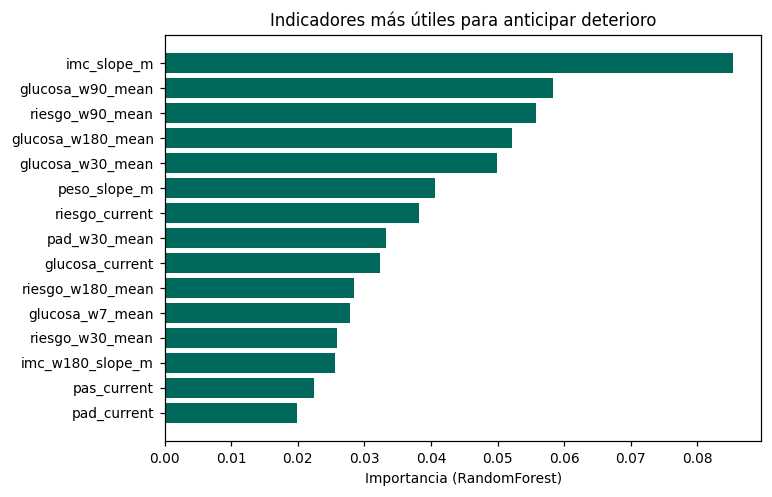

,feature,importance
0,imc_slope_m,0.085385
1,glucosa_w90_mean,0.058297
2,riesgo_w90_mean,0.055817
3,glucosa_w180_mean,0.052122
4,glucosa_w30_mean,0.049961
5,peso_slope_m,0.040665
6,riesgo_current,0.038180
7,pad_w30_mean,0.033243
8,glucosa_current,0.032281
9,riesgo_w180_mean,0.028442


In [5]:
show(FIG/'validation'/'indicator_importance.png')
pd.read_csv(MET/'indicator_usefulness.csv').head(12)

## Dashboards clínicos integrales (Fase 2H)

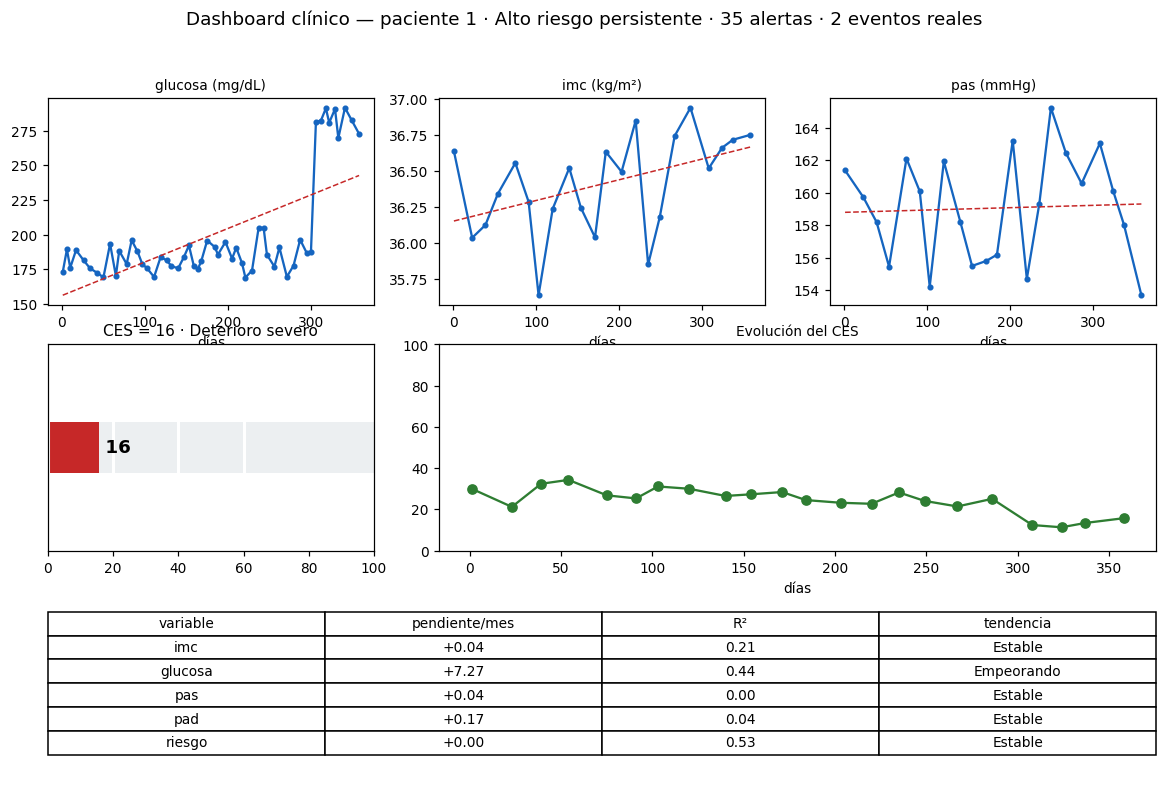

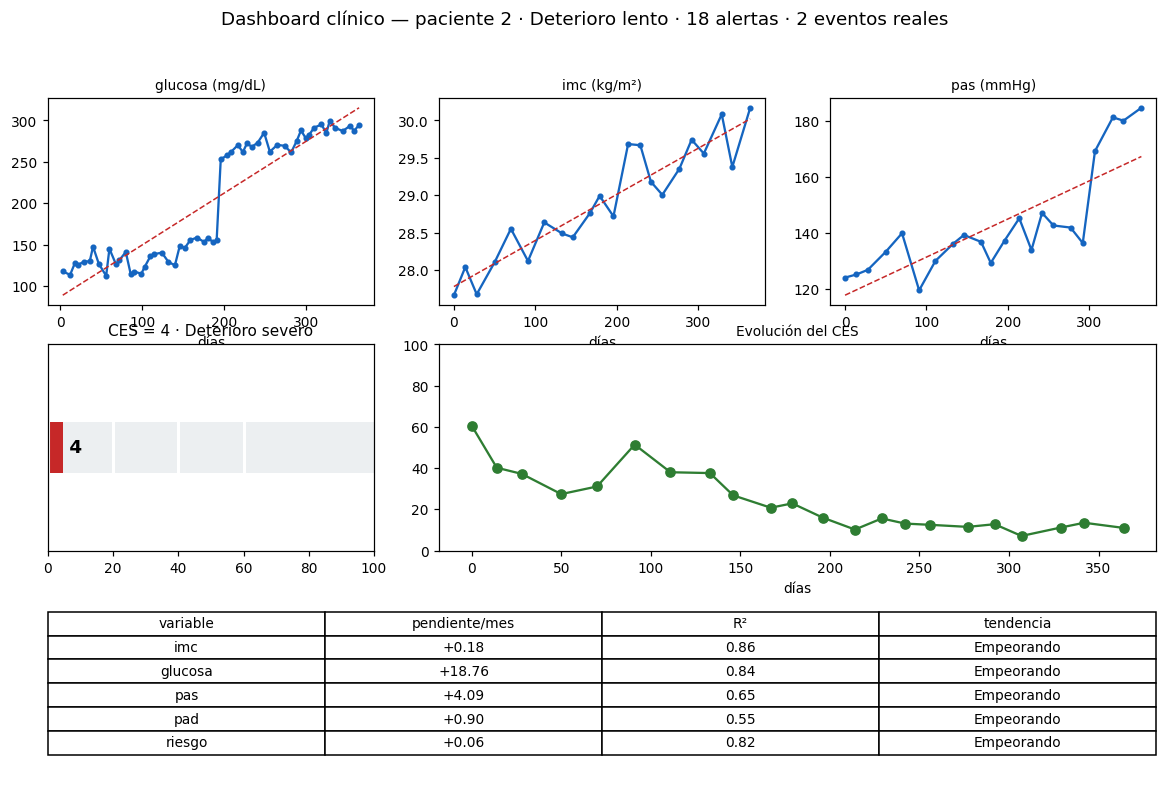

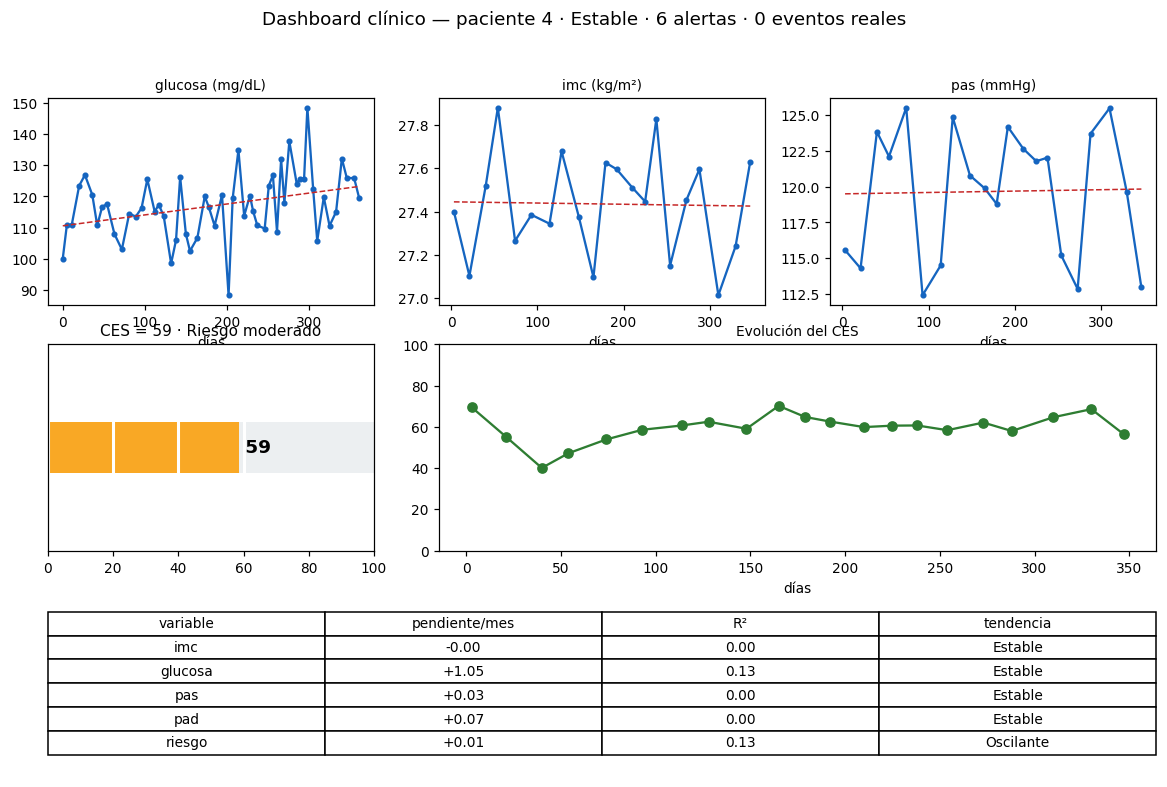

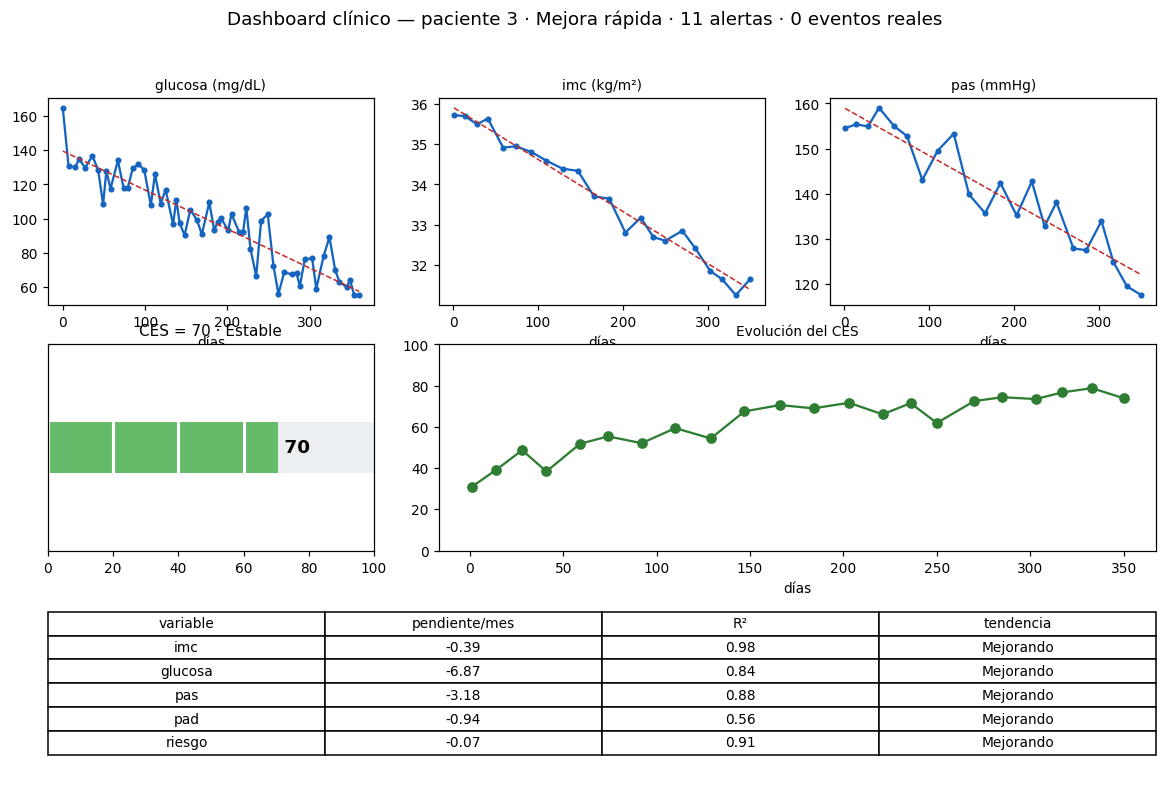

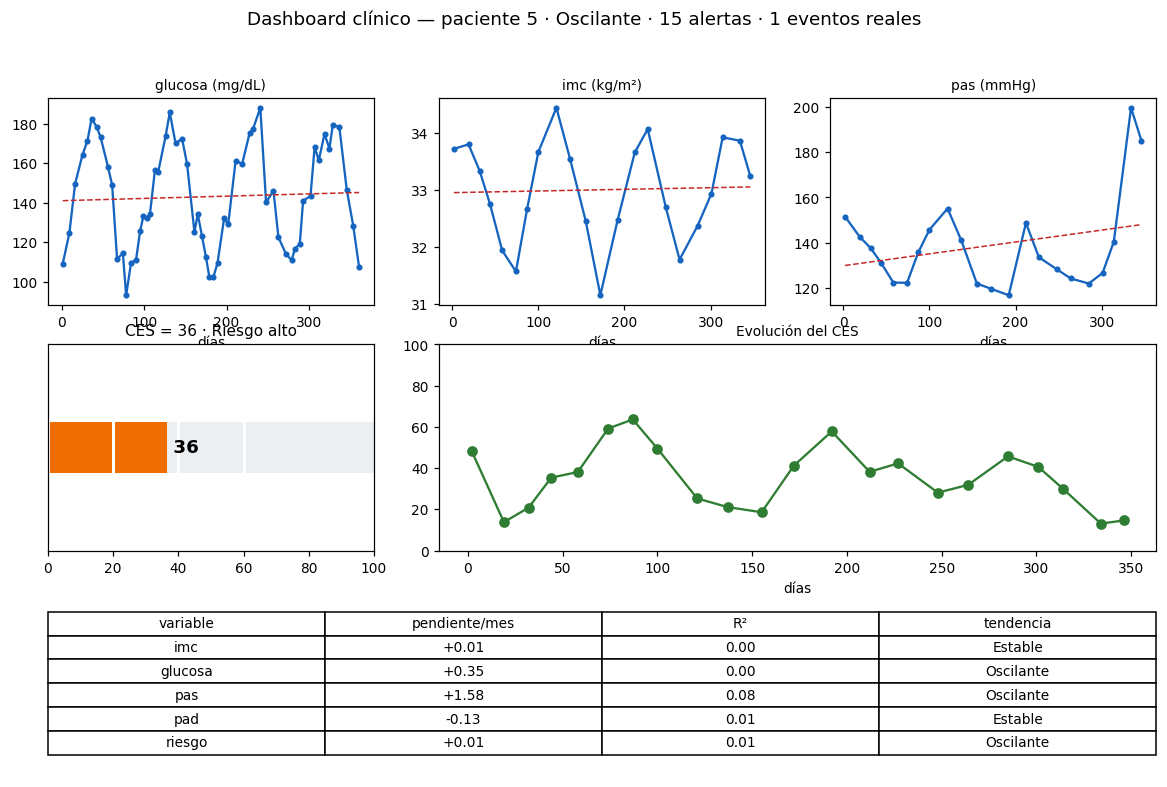

In [6]:
for p in sorted(DASH.glob('dashboard_*.png')): show(p)

### Conclusión 2I
- **Interpretables:** cada tendencia/banda se explica por su pendiente, R² y componentes del CES.
- **Recuperan estructura real:** clustering con ARI alto y CES ordenado por arquetipo.
- **Intervención temprana:** las alertas preceden a los eventos (lead-time > 0).
- **Indicadores clave:** glucosa, riesgo e IMC (pendientes y nivel) dominan la anticipación del deterioro.

El framework responde *¿cómo evolucionó?, ¿mejora o empeora?, ¿qué tan rápido?, ¿qué tan probable es que empeore?* — listo para integrarse en PREDIA (ver `Temporal_Clinical_Evolution_Framework_Report.md`).